In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


https://www.google.com/search?q=tolerance+in+pdes&oq=tolerance+in+pdes&gs_lcrp=EgZjaHJvbWUyBggAEEUYOdIBCDU4MjNqMGoxqAIAsAIA&sourceid=chrome&ie=UTF-8#fpstate=ive&vld=cid:c2eda3a1,vid:c4LwNoh8ZBM,st:0

#Ejercicio 1.

**1.**

La solución cenvergió en 235 pasos
La tolerancia es: 0.09977668457244704


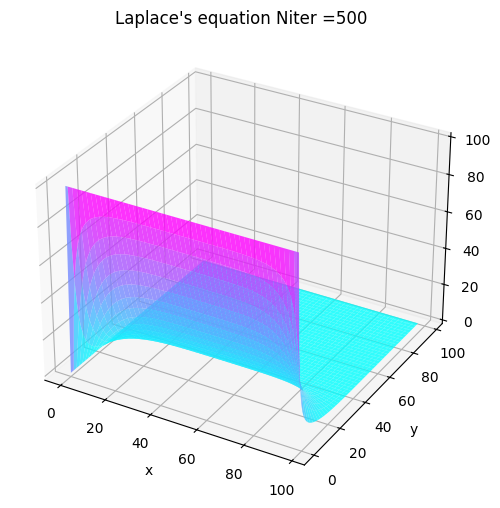

In [28]:
L, Niter = 100, 500

V = np.zeros((L, L), float) # grid in 0V.

for k in range(0, L):
  for j in range(0, L):
     V[0,j] = 0.0
     V[k,0] = 100.0 # let line at 100V

for iter in range(Niter): # iterations over algorithm. Niter times
  V_last=V.copy()
  for i in range(1, L-1):
    for j in range(1,L-1):
      V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])
  tol=np.max(np.abs(V-V_last))
  if tol > 10**-6:
    if  tol < 10**-1:
      print(f"La solución cenvergió en {iter+1} pasos")
      break
else:
  print("La solución falló en converger")

print('La tolerancia es:', tol) #Tolerancia
#Do the grid to plot
x = np.arange(0, L-1, 1)
y = x
X, Y = np.meshgrid(x,y)

def functz(V,X,Y): # Function returns V(x, y)
  z = V[X,Y]
  return z

Z = functz(V,X,Y)

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)

ax.set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()


La solución falló en converger en 1 pasos
La solución falló en converger en 2 pasos
La solución falló en converger en 3 pasos
La solución falló en converger en 4 pasos
La solución falló en converger en 5 pasos
La solución falló en converger en 6 pasos
La solución falló en converger en 7 pasos
La solución falló en converger en 8 pasos
La solución falló en converger en 9 pasos
La solución falló en converger en 10 pasos
La solución falló en converger en 11 pasos
La solución falló en converger en 12 pasos
La solución falló en converger en 13 pasos
La solución falló en converger en 14 pasos
La solución falló en converger en 15 pasos
La solución falló en converger en 16 pasos
La solución falló en converger en 17 pasos
La solución falló en converger en 18 pasos
La solución falló en converger en 19 pasos
La solución falló en converger en 20 pasos
La solución falló en converger en 21 pasos
La solución falló en converger en 22 pasos
La solución falló en converger en 23 pasos
La solución falló en

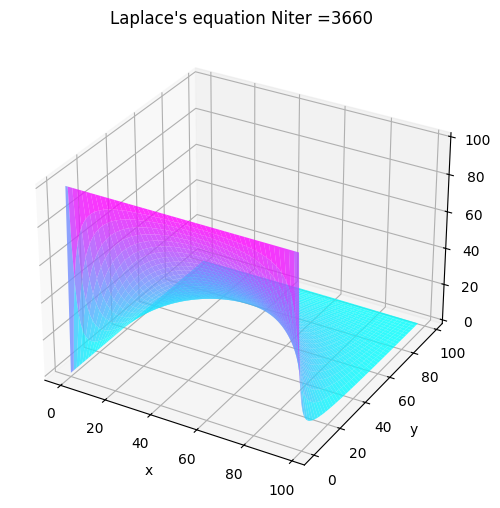

In [39]:
L, Niter = 100, 3660

V = np.zeros((L, L), float) # grid in 0V.

for k in range(0, L):
  for j in range(0, L):
     V[0,j] = 0.0
     V[k,0] = 100.0 # let line at 100V

for iter in range(Niter): # iterations over algorithm. Niter times
  V_last=V.copy()
  for i in range(1, L-1):
    for j in range(1,L-1):
      V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])
  tol=np.max(np.abs(V-V_last))
  if tol < 10**-3:
    print(f"La solución convergió en {iter+1} pasos")
    break
  else:
    print(f"La solución falló en converger en {iter+1} pasos")
print('La tolerancia es:', tol) #Tolerancia
#Do the grid to plot
x = np.arange(0, L-1, 1)
y = x
X, Y = np.meshgrid(x,y)

def functz(V,X,Y): # Function returns V(x, y)
  z = V[X,Y]
  return z

Z = functz(V,X,Y)

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)

ax.set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

Se implementó una cota superior de $10^{-3}$ y se midió el número de iteraciones necesarias para lograr la convergencia con la tolerancia necesaria.

**3.**

La solución analítica del problema está dada por la serie de Fourier:

$u(x,y) = \sum_{n=1,3,5\dots}^{\infty} \frac{400}{n\pi \sinh(n\pi)} \sin\left(\frac{n\pi x}{L}\right) \sinh\left(\frac{n\pi}{L}(L-y)\right)$




Calculando la serie de Fourier...
Convergencia alcanzada. Se detuvo en n = 99.
Total de términos impares sumados: 49
9.20177243397509e-14


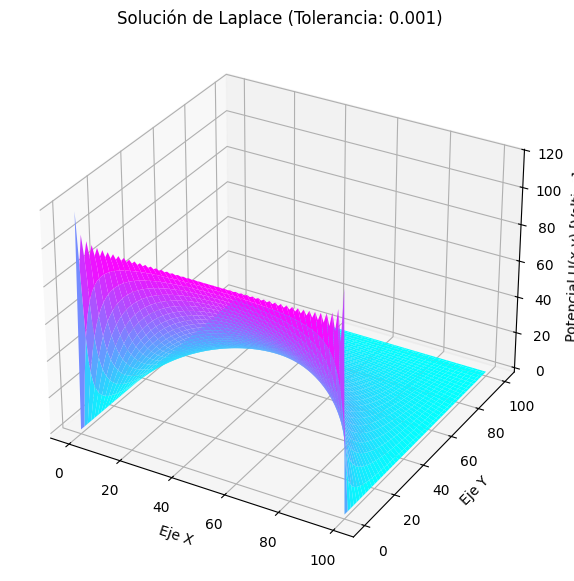

In [77]:


L = 100
V0 = 100.0
tolerancia = 1e-3

# Creación de la malla
x = np.linspace(0, L, 100)
y = np.linspace(0, L, 100)
X, Y = np.meshgrid(x, y)


U = np.zeros_like(X)

# Cálculo de la Serie de Fourier con Tolerancia
n = 1
terminos_sumados = 0

print("Calculando la serie de Fourier...")

while True:

    try:
        An = 400.0 / (n * np.pi * np.sinh(n * np.pi))
    except OverflowError:
        print(f"Límite numérico alcanzado en n={n}. Deteniendo.")
        break


    term = An * np.sin(n * np.pi * X / L) * np.sinh(n * np.pi * (L - Y) / L)


    max_aporte = np.max(np.abs(term))

    if max_aporte < tolerancia:
        print(f"Convergencia alcanzada. Se detuvo en n = {n}.")
        print(f"Total de términos impares sumados: {terminos_sumados}")
        break


    U += term


    n += 2 #Se suman impares
    terminos_sumados += 1
print(max_aporte)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')


surf = ax.plot_surface(X, Y, U,cmap='cool')


ax.set_title(f'Solución de Laplace (Tolerancia: {tolerancia})')
ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.set_zlabel('Potencial U(x,y) [Voltios]')




plt.show()

#Ejercicio 2.

De la ecuación de Laplace
$$\nabla^2 u = \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = 0$$

Proponiendo la solución:
$$u(x,y) = X(x)Y(y)$$


Se obtienen las ecuaciones
$$X''(x) + k^2 X(x) = 0$$
$$Y''(y) - k^2 Y(y) = 0$$

La solución general para la ecuación diferencial en $x$ es:
$$X(x) = A \cos(kx) + B \sin(kx)$$

Aplicando las condiciones de frontera laterales:
$X(0) = A \cos(0) + B \sin(0) = 0 \implies A = 0$
Así:

$X(x) = B \sin(kx)$.$

   $$X(L) = B \sin(kL) = 0$$
     $\sin(kL) = 0$. Esto se cumple cuando $kL = n\pi$ para $n = 1, 2, 3, \dots$
     $k_n = \frac{n\pi}{L}$.  
    



Las funciones propias espaciales son:
$$X_n(x) = \sin\left(\frac{n\pi x}{L}\right)$$

Utilizando los valores de $k_n$, la solución general para $y$  es:
$$Y_n(y) = C e^{k_n y} + D e^{-k_n y}$$

Aplicamos la condición de frontera en el infinito:
 $$u(x,\infty) = 0 \implies Y_n(\infty) = 0$$El término $e^{k_n y}$ diverge hacia infinito cuando $y \to \infty$. Para que el potencial se anule físicamente a grandes distancias, su coeficiente debe ser cero, es decir, $C = 0$.
    
   

$$Y_n(y) = D e^{-\frac{n\pi y}{L}}$$


Por el principio de superposición, la solución general es la suma lineal de todos los modos posibles:
$$u(x,y) = \sum_{n=1}^{\infty} B_n \sin\left(\frac{n\pi x}{L}\right) e^{-\frac{n\pi y}{L}}$$

Finalmente, aplicamos la condición de frontera en $y = 0$ para encontrar los coeficientes $B_n$:
$$u(x,0) = \sum_{n=1}^{\infty} B_n \sin\left(\frac{n\pi x}{L}\right) e^{0} = \sum_{n=1}^{\infty} B_n \sin\left(\frac{n\pi x}{L}\right)$$

Igualamos esto con la función dada en el borde inferior:
$$\sum_{n=1}^{\infty} B_n \sin\left(\frac{n\pi x}{L}\right) = u_0 \sin\left(\frac{2\pi x}{L}\right)$$


Igualando término a término el único término que sobrevive en la sumatoria infinita es el de **$n = 2$**.

* Para $n = 2$: $B_2 = u_0$
* Para $n \neq 2$: $B_n = 0$

Sustituyendo $n=2$ y $B_2$. La solución analítica exacta es:

$$u(x,y) = u_0 \sin\left(\frac{2\pi x}{L}\right) e^{-\frac{2\pi y}{L}}$$



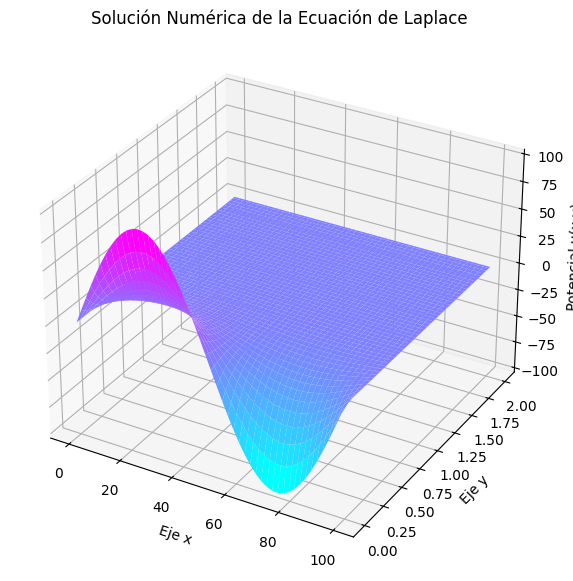

In [95]:
L = 100
u0 = 100.0
Y_max = 2.0
max_iter = 1000
Nx = 50
Ny = 100
x = np.linspace(0, L, Nx)
y = np.linspace(0, Y_max, Ny)
X, Y = np.meshgrid(x, y)
V = np.zeros((Ny, Nx))
V
V[0, :] = u0 * np.sin(2 * np.pi * x / L)

for iteracion in range(max_iter):

    for j in range(1, Ny - 1):
        for i in range(1, Nx - 1):

            V[j, i] = 0.25 * (V[j+1, i] + V[j-1, i] + V[j, i+1] + V[j, i-1])


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, V, cmap='cool')

ax.set_title('Solución Numérica de la Ecuación de Laplace')
ax.set_xlabel('Eje x')
ax.set_ylabel('Eje y')
ax.set_zlabel('Potencial u(x,y)')



plt.show()